In [24]:
! pip install Pillow


[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np
from scipy import signal
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from matplotlib.ticker import FormatStrFormatter
import math
from PIL import Image, ImageDraw

## 1.グリッドの定義と描画

### 入力
- フロアマップの幅[px] : 2,837px ` map_width_px (int)`
- フロアマップの高さ[px]:  3,742px `map_height_px (int)`
- グリッドの一辺の長さ[px] : 30px `grid_size_px (int)`

### 出力
- 横方向のグリッド数 95 `num_grids_x`
- 縦方向のグリッド数 125 `num_grids_y`

### アルゴリズム
フロアマップの寸法とグリッドサイズから、横方向と縦方向にいくつのグリッドができるかを計算
- 横方向のグリッド数： $N_x = \lceil W / G \rceil = \lceil 2837 / 30 \rceil = \lceil 94.56... \rceil = 95$
- 縦方向のグリッド数： $N_y = \lceil H / G \rceil = \lceil 3742 / 30 \rceil = \lceil 124.73... \rceil = 125$



/var/folders/0m/59kfg8d93117cwwrsg6slc_80000gn/T/ipykernel_69180/856189993.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend() # 凡例表示


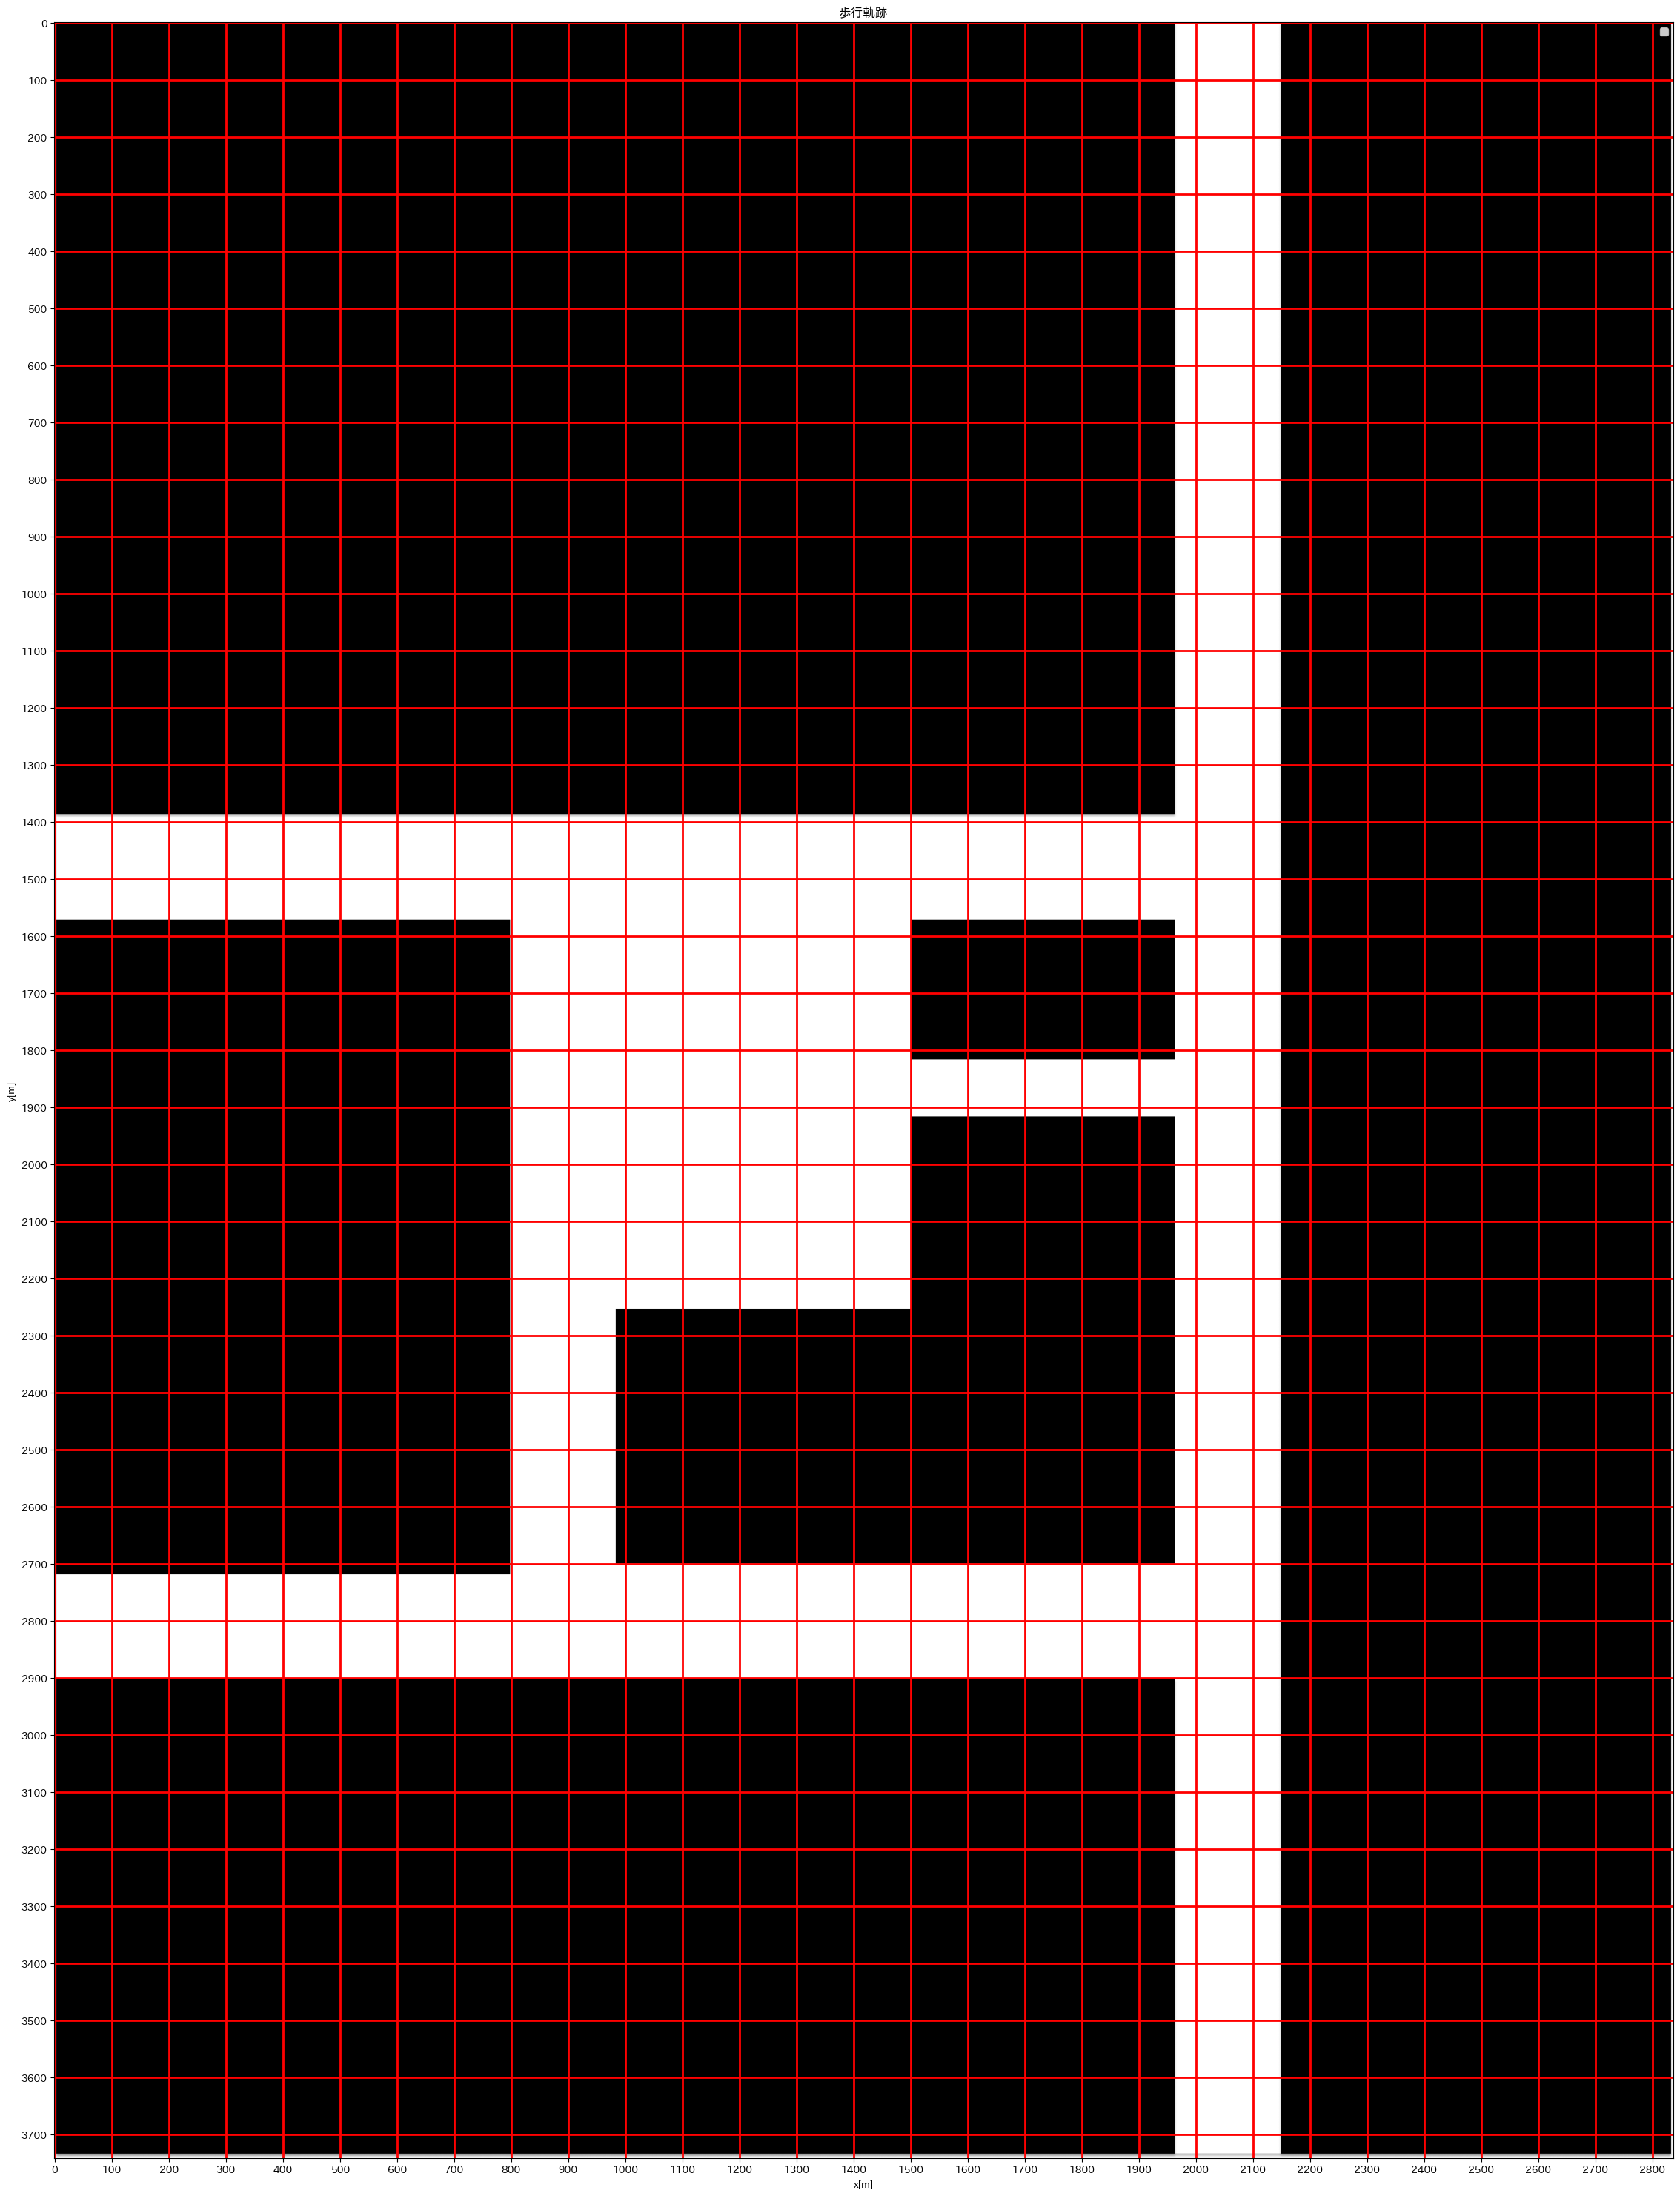

--- グリッド定義 ---
フロアマップの幅: 2837 px
フロアマップの高さ: 3742 px
グリッドサイズ: 100 px
横方向のグリッド数 (Nx): 29
縦方向のグリッド数 (Ny): 38
--------------------


In [ ]:
# 1. グリッドの定義
# 提供されたフロアマップの寸法を使用
map_width = 2837
map_height = 3742
# 提案されたグリッドサイズ
grid_size = 100 


num_grids_x = math.ceil(map_width / grid_size)
num_grids_y = math.ceil(map_height / grid_size)

img = Image.open("../../docs/floorMap/building＝14,floor=5_freeSpace.png")

# プロットの設定
fig, ax = plt.subplots(figsize=(map_width/100, map_height/100), dpi=100)
ax.imshow(img)

# グリッドの間隔を設定
# MultipleLocatorを使って、指定したgrid_sizeごとにグリッド線を表示
ax.xaxis.set_major_locator(ticker.MultipleLocator(grid_size))
ax.yaxis.set_major_locator(ticker.MultipleLocator(grid_size))


# グリッドを表示
ax.grid(which='major', color='red', linestyle='-', linewidth=2)



# 画像を表示
plt.title('フロアマップにグリッドを描画')
plt.xlabel('幅[px]')
plt.ylabel('高さ[px]')
plt.show()
img.save("output/gridFloorMap.png")




print(f"--- グリッド定義 ---")
print(f"フロアマップの幅: {map_width} px")
print(f"フロアマップの高さ: {map_height} px")
print(f"グリッドサイズ: {grid_size} px")
print(f"横方向のグリッド数 (Nx): {num_grids_x}")
print(f"縦方向のグリッド数 (Ny): {num_grids_y}")
print("-" * 20)


## 2.各グリッドにIDを割り振る

In [ ]:

grid_data = []  # 各グリッドの情報を格納するためのリスト
grid_id = 0     # グリッドIDの初期値

for y in range(num_grids_y):
    for x in range(num_grids_x):
        # グリッドの中心座標を計算 (IDを描画する位置)
        center_x = x * grid_size + grid_size / 2
        center_y = y * grid_size + grid_size / 2

        # グリッドの中心にIDを描画
        ax.text(center_x, center_y, str(grid_id), color='blue',
                ha='center', va='center', fontsize=6)

        # グリッドの情報を辞書として保存
        grid_info = {
            'id': grid_id,
            'x_min': x * grid_size,
            'y_min': y * grid_size,
            'x_max': (x + 1) * grid_size,
            'y_max': (y + 1) * grid_size
        }
        grid_data.append(grid_info)

        grid_id += 1

## 座標マッピング関数
歩行者の (x, y) 座標をグリッドの行インデックス、列インデックス、およびユニークなセルIDにマッピングします。


### 入力
- 歩行者のx座標:150? `px`
- 歩行者のy座標:200? `py`
- グリッドサイズ : 30`grid_size_px`
- 横方向のグリッド数 : 95 `num_grids_x`
- 横方向のグリッド数 : 125`num_grids_y`

### 出力
 (6, 5, '6_5')


### アルゴリズム
- row = floor(200 / 30) = floor(6.66...) = 6
- col = floor(150 / 30) = floor(5) = 5
- cell_id = "6_5"

- `math.floor()` を使用して、与えられた座標がどのグリッドの行と列に属するかを計算します。
-  計算された行と列から、`'row_col'`形式のユニークなセルIDを生成します。
- 座標がマップの有効範囲外である場合は `(None, None, None)` を返します。


## 使用例